# Лабораторная работа №4. Задача регрессии

In [ ]:
import pickle

import pandas as pd
from catboost import CatBoostRegressor
from daal4py.sklearn.linear_model import ElasticNet
from sklearn.ensemble import BaggingRegressor, AdaBoostRegressor, StackingRegressor
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearnex.ensemble import RandomForestRegressor
from matplotlib import pyplot as plt
import seaborn as sns


RANDOM_STATE = 13

## Загрузка данных и разделение выборки

In [2]:
data = pd.read_csv("datasets/air.csv", index_col="Unnamed: 0")
data

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,day,month,day_of_week,hour,year
0,0.211864,0.511845,0.226923,0.408251,0.118241,0.493333,0.513040,0.455614,0.333333,0.499371,0.280066,0.3,3,3,18,2004
1,0.161017,0.463029,0.178846,0.352217,0.072819,0.400000,0.453237,0.326806,0.326882,0.484277,0.264282,0.3,3,3,19,2004
2,0.177966,0.541996,0.171154,0.342365,0.093006,0.497778,0.451439,0.371192,0.296774,0.563522,0.276352,0.3,3,3,20,2004
3,0.177966,0.523331,0.175000,0.347906,0.122567,0.533333,0.464478,0.427328,0.277419,0.638994,0.294190,0.3,3,3,21,2004
4,0.127119,0.448672,0.123077,0.278941,0.093006,0.506667,0.422212,0.386858,0.281720,0.633962,0.295216,0.3,3,3,22,2004
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,0.254237,0.478823,0.257692,0.442118,0.338861,0.835556,0.370054,0.656223,0.511828,0.252830,0.279578,0.1,4,1,10,2005
9353,0.194915,0.370424,0.217308,0.396552,0.253064,0.786667,0.320594,0.456049,0.563441,0.182390,0.257636,0.1,4,1,11,2005
9354,0.194915,0.355348,0.236538,0.418719,0.209805,0.768889,0.310252,0.379025,0.619355,0.114465,0.222792,0.1,4,1,12,2005
9355,0.169492,0.255564,0.180769,0.355911,0.167988,0.684444,0.220324,0.238903,0.649462,0.054088,0.160876,0.1,4,1,13,2005


Разделим выборку в формате 80 - 10 - 10

In [3]:
X = data.drop("CO(GT)", axis=1)
y = data["CO(GT)"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2)
X_val, X_test, y_val, y_test =  train_test_split(X_val_test, y_val_test, test_size=0.5)

print(f"Размер тренировочной выборки: {len(X_train)}\n"
      f"Размер валидационной выборки: {len(X_val)}\n"
      f"Размер тестовой выборки: {len(X_test)}")

Размер тренировочной выборки: 7100
Размер валидационной выборки: 887
Размер тестовой выборки: 888


## Обучение моделей

In [12]:
import optuna
from sklearn.model_selection import cross_val_score, RandomizedSearchCV, GridSearchCV

def train_models_with_cross_val(X_train, y_train, models_config):

    result={}

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        model_obj = model_info["model"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator= model_obj(),
            scoring="r2",
            cv=5,
            n_jobs=8
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=model_obj(),
            scoring="r2",
            random_state=RANDOM_STATE,
            cv=5,
            n_jobs=8
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values))
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            current_model = model_obj(**trial_params,random_state=RANDOM_STATE)

            score = cross_val_score(current_model, X_train, y_train, cv=5, scoring='r2').mean()
            return score

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=15, show_progress_bar=False)

        final_optuna_model = model_obj(**study.best_params,random_state=RANDOM_STATE)
        final_optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": final_optuna_model,
            "best_params": study.best_params
        }

    return result

In [4]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

### Деревья решений

In [38]:
dt_config = {
    "DT": {
        "model": DecisionTreeRegressor,
        "param_grid": {
            "criterion": ["squared_error", "friedman_mse", "absolute_error"],
            "max_depth": [None, 3, 5, 10, 15, 20, 30],
            "min_samples_split": [2, 5, 10, 20],
            "min_samples_leaf": [1, 2, 5, 10],
            "max_features": [None, "sqrt", "log2"],
            "ccp_alpha": np.logspace(-4, -1, 10).tolist()
        }
    }
}

In [ ]:
tree_models = train_models_with_cross_val(X_train, y_train, dt_config)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, \
    root_mean_squared_error


def get_scores(y_true, y_pred):
        r2 = round(r2_score(y_true, y_pred), 2)
        mse = round(mean_squared_error(y_true, y_pred), 4)
        rmse = round(root_mean_squared_error(y_true, y_pred), 4)
        mae = round(mean_absolute_error(y_true, y_pred), 4)
        mape = round(mean_absolute_percentage_error(y_true, y_pred), 4)
        return [r2, mse, rmse, mae, mape]

def input_into_table(Xtrain, Xtest, ytrain, ytest, model, name_of_model):
    train_pred = model.predict(Xtrain)
    test_pred = model.predict(Xtest)

    train_and_test_comparing.loc[name_of_model] = (get_scores(ytrain, train_pred)
                                                   + get_scores(ytest, test_pred))

In [41]:
tree_models.items()

dict_items([('DT', {'GridSearch': {'model': DecisionTreeRegressor(ccp_alpha=0.0001, criterion='absolute_error',
                      min_samples_leaf=5), 'best_params': {'ccp_alpha': 0.0001, 'criterion': 'absolute_error', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}}, 'RandomSearch': {'model': DecisionTreeRegressor(ccp_alpha=0.0001, criterion='absolute_error',
                      max_depth=15, min_samples_split=10), 'best_params': {'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'criterion': 'absolute_error', 'ccp_alpha': 0.0001}}, 'Optuna': {'model': DecisionTreeRegressor(ccp_alpha=0.0007013087556190303,
                      criterion='absolute_error', max_depth=15,
                      min_samples_leaf=5, min_samples_split=5, random_state=13), 'best_params': {'criterion': 'absolute_error', 'max_depth': 15, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': None, 'ccp_alpha': 0.000701308

Text(0.5, 0.98, 'DecisionTreeRegressor')

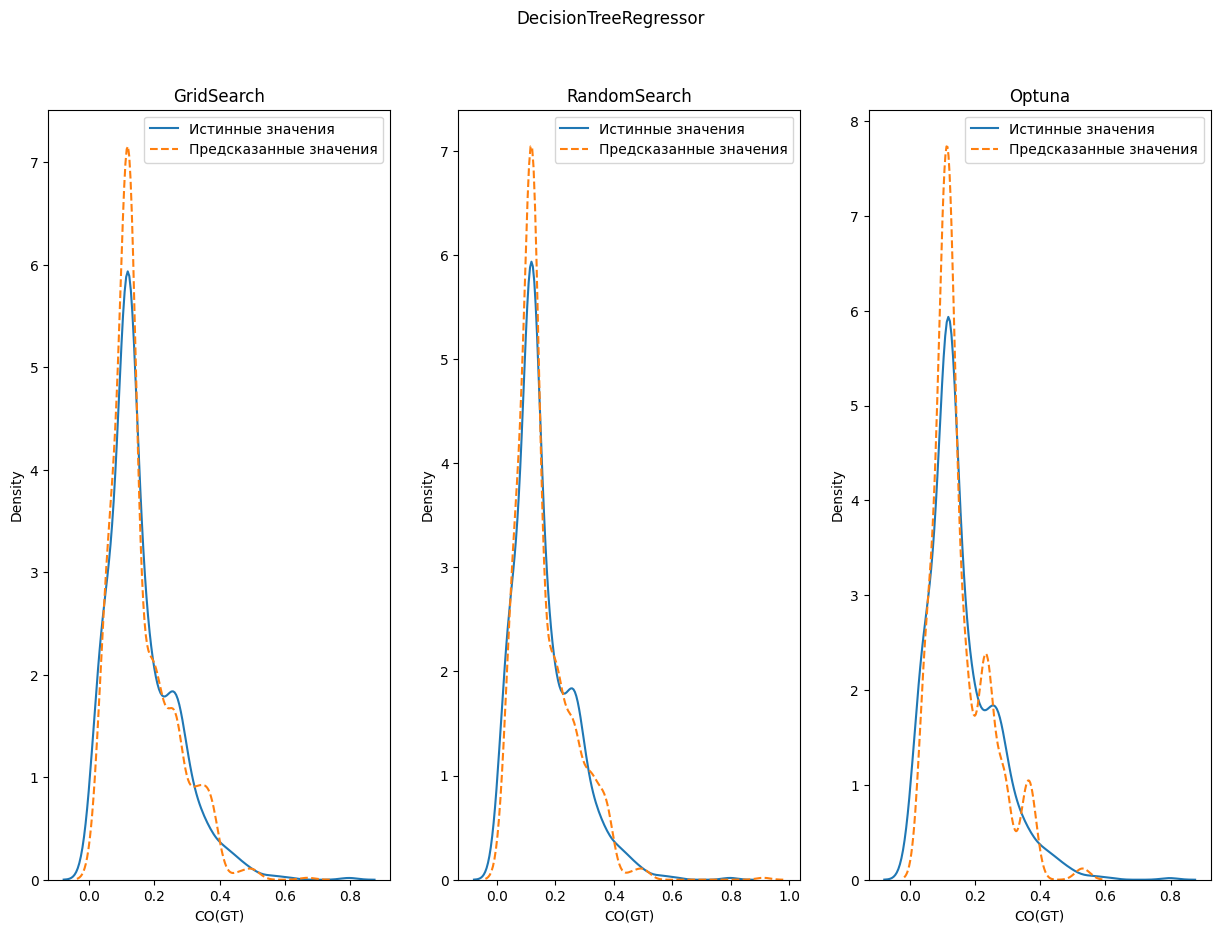

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, tree_models["DT"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"DecisionTreeRegressor ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("DecisionTreeRegressor")

In [50]:
train_and_test_comparing

Train Data                          \
                                             R2     MSE    RMSE     MAE   
DecisionTreeRegressor (GridSearch)         0.83  0.0018  0.0420  0.0255   
DecisionTreeRegressor (RandomSearch)       0.84  0.0017  0.0415  0.0254   
DecisionTreeRegressor (Optuna)             0.78  0.0023  0.0481  0.0312   

                                                   Test Data                  \
                                              MAPE        R2     MSE    RMSE   
DecisionTreeRegressor (GridSearch)    1.333126e+12      0.85  0.0016  0.0400   
DecisionTreeRegressor (RandomSearch)  1.333126e+12      0.85  0.0016  0.0399   
DecisionTreeRegressor (Optuna)        1.532019e+12      0.81  0.0020  0.0447   

                                                            
                                         MAE          MAPE  
DecisionTreeRegressor (GridSearch)    0.0267  6.446976e+11  
DecisionTreeRegressor (RandomSearch)  0.0267  6.446976e+11  
DecisionTreeRegressor (Optuna)        0.0313  6.446976e+11

## Бэггинг-регрессор

Для бэггинга применим лучшую модель, полученную в результате 2 лабораторной работы - полиномиальная регрессия 3 степени с Elastic-Net регуляризацией.

In [54]:
pipeline = Pipeline([("poly", PolynomialFeatures(degree=3)),
                     ("model", ElasticNet(alpha=0.001, l1_ratio=0.1,))])

bag_reg = BaggingRegressor(estimator=pipeline, random_state=RANDOM_STATE)

bag_reg.fit(X_train, y_train)
input_into_table(X_train, X_test, y_train, y_test, bag_reg, "Bagging regressor")

In [55]:
train_and_test_comparing

Train Data                          \
                                             R2     MSE    RMSE     MAE   
DecisionTreeRegressor (GridSearch)         0.83  0.0018  0.0420  0.0255   
DecisionTreeRegressor (RandomSearch)       0.84  0.0017  0.0415  0.0254   
DecisionTreeRegressor (Optuna)             0.78  0.0023  0.0481  0.0312   
Bagging regressor                          0.88  0.0012  0.0352  0.0241   

                                                   Test Data                  \
                                              MAPE        R2     MSE    RMSE   
DecisionTreeRegressor (GridSearch)    1.333126e+12      0.85  0.0016  0.0400   
DecisionTreeRegressor (RandomSearch)  1.333126e+12      0.85  0.0016  0.0399   
DecisionTreeRegressor (Optuna)        1.532019e+12      0.81  0.0020  0.0447   
Bagging regressor                     1.245275e+12      0.89  0.0011  0.0334   

                                                            
                                         MAE          MAPE  
DecisionTreeRegressor (GridSearch)    0.0267  6.446976e+11  
DecisionTreeRegressor (RandomSearch)  0.0267  6.446976e+11  
DecisionTreeRegressor (Optuna)        0.0313  6.446976e+11  
Bagging regressor                     0.0243  6.126612e+11

Применение бэггинга пока что показало лучшие результаты: метрика R2 равна 0.89.

Text(0.5, 1.0, 'Bagging regressor')

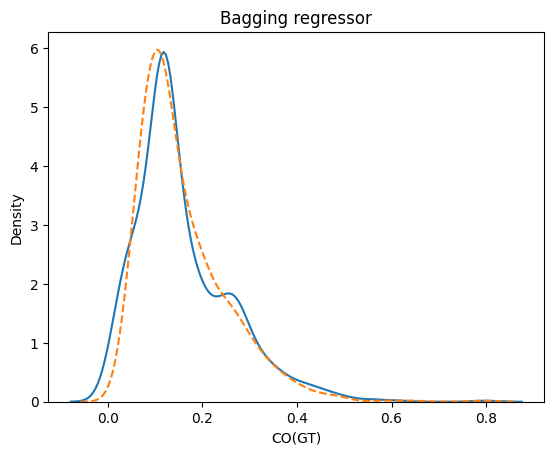

In [56]:
predict = bag_reg.predict(X_test)
sns.kdeplot(y_test, label="Истинные значения")
sns.kdeplot(predict, label="Предсказанные значения", linestyle="--")
plt.title("Bagging regressor")

### Случайный лес

In [61]:
forest_config = {
    "Random Forest":{
        "model": RandomForestRegressor,
        "param_grid":{
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4],
                'max_features': ['sqrt', 'log2', None],
        }
    }

}

In [62]:
random_forest_models = train_models_with_cross_val(X_train, y_train, forest_config)

[I 2026-04-15 20:04:38,548] A new study created in memory with name: no-name-3c4209dc-d38d-4bc6-9c2e-3b357609729d
[I 2026-04-15 20:04:39,043] Trial 0 finished with value: 0.8924826717091292 and parameters: {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.8924826717091292.
[I 2026-04-15 20:04:39,774] Trial 1 finished with value: 0.8952819078923018 and parameters: {'n_estimators': 300, 'max_depth': None, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.8952819078923018.
[I 2026-04-15 20:04:41,069] Trial 2 finished with value: 0.8903081408214805 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 1 with value: 0.8952819078923018.
[I 2026-04-15 20:04:42,120] Trial 3 finished with value: 0.8978603942469162 and parameters: {'n_estimators': 300, 'max_depth': 20,

Text(0.5, 0.98, 'RandomForestRegressor')

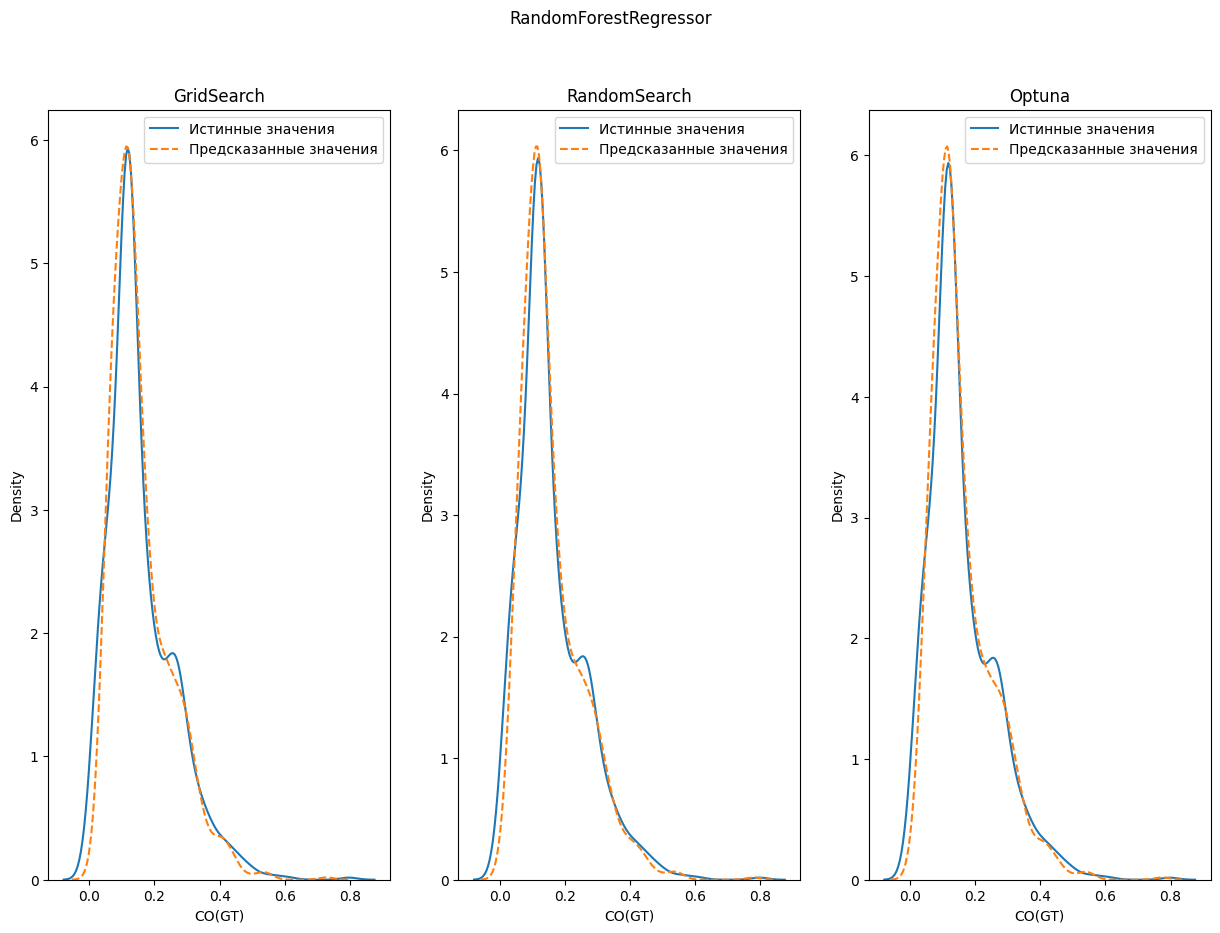

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, random_forest_models["Random Forest"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"Random Forest Regressor ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("RandomForestRegressor")

In [65]:
train_and_test_comparing

Train Data                          \
                                               R2     MSE    RMSE     MAE   
DecisionTreeRegressor (GridSearch)           0.83  0.0018  0.0420  0.0255   
DecisionTreeRegressor (RandomSearch)         0.84  0.0017  0.0415  0.0254   
DecisionTreeRegressor (Optuna)               0.78  0.0023  0.0481  0.0312   
Bagging regressor                            0.88  0.0012  0.0352  0.0241   
Random Forest Regressor (GridSearch)         0.99  0.0002  0.0123  0.0077   
Random Forest Regressor (RandomSearch)       0.99  0.0002  0.0124  0.0076   
Random Forest Regressor (Optuna)             0.99  0.0002  0.0125  0.0077   

                                                     Test Data          \
                                                MAPE        R2     MSE   
DecisionTreeRegressor (GridSearch)      1.333126e+12      0.85  0.0016   
DecisionTreeRegressor (RandomSearch)    1.333126e+12      0.85  0.0016   
DecisionTreeRegressor (Optuna)          1.532019e+12      0.81  0.0020   
Bagging regressor                       1.245275e+12      0.89  0.0011   
Random Forest Regressor (GridSearch)    4.160194e+11      0.91  0.0009   
Random Forest Regressor (RandomSearch)  4.114144e+11      0.91  0.0009   
Random Forest Regressor (Optuna)        4.166855e+11      0.91  0.0009   

                                                                      
                                          RMSE     MAE          MAPE  
DecisionTreeRegressor (GridSearch)      0.0400  0.0267  6.446976e+11  
DecisionTreeRegressor (RandomSearch)    0.0399  0.0267  6.446976e+11  
DecisionTreeRegressor (Optuna)          0.0447  0.0313  6.446976e+11  
Bagging regressor                       0.0334  0.0243  6.126612e+11  
Random Forest Regressor (GridSearch)    0.0299  0.0208  6.760729e+11  
Random Forest Regressor (RandomSearch)  0.0300  0.0206  5.838811e+11  
Random Forest Regressor (Optuna)        0.0300  0.0204  5.888238e+11

Модель случайного леса показала еще лучшие результаты, чем предыдущие модели. Значение R2 возросло до 0.91.

### GradientBoostingRegressor


In [8]:
from sklearn.ensemble import GradientBoostingRegressor

gb_config = {
    "Gradient Boosting": {
        "model": GradientBoostingRegressor,
        "param_grid": {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 8],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', None],
        }
    }
}

In [13]:
gb_models = train_models_with_cross_val(X_train, y_train, gb_config)

[I 2026-04-16 07:36:14,684] A new study created in memory with name: no-name-3969b0db-64be-4284-b209-623480cf6a2d
[I 2026-04-16 07:36:17,532] Trial 0 finished with value: 0.9085845468026637 and parameters: {'n_estimators': 100, 'learning_rate': 0.07043979233676825, 'max_depth': 8, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.9085845468026637.
[I 2026-04-16 07:36:21,147] Trial 1 finished with value: 0.9039547561440185 and parameters: {'n_estimators': 200, 'learning_rate': 0.06705557557500344, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9085845468026637.
[I 2026-04-16 07:36:23,005] Trial 2 finished with value: 0.8822817120491748 and parameters: {'n_estimators': 100, 'learning_rate': 0.0411228667790344, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9085845468026637.
[I 2026-04-16 07:36:2

Text(0.5, 0.98, 'GradientBoostingRegressor')

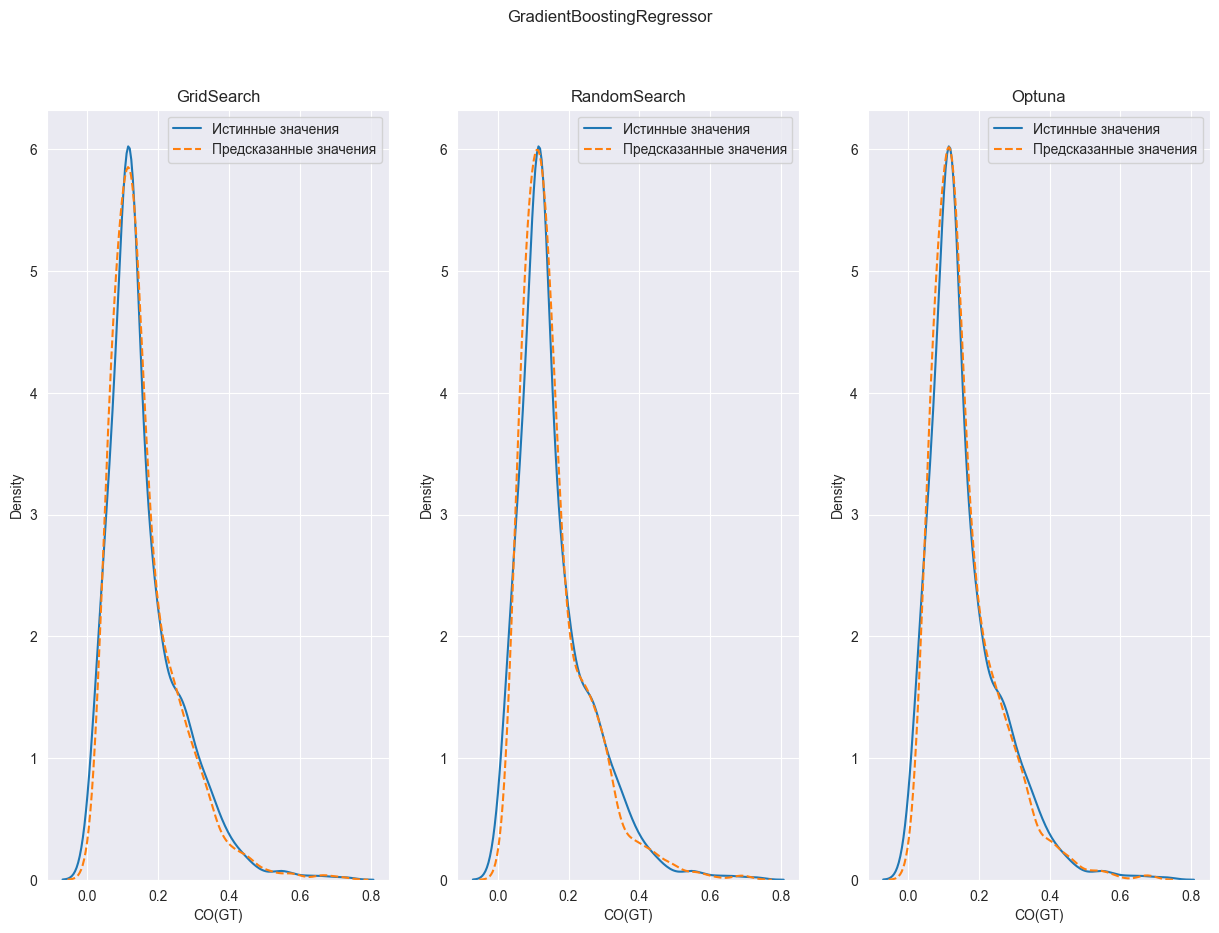

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, gb_models["Gradient Boosting"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"GradientBoostingRegressor ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("GradientBoostingRegressor")

In [20]:
train_and_test_comparing

Train Data                          \
                                                 R2     MSE    RMSE     MAE   
GradientBoostingRegressor (GridSearch)         0.99  0.0001  0.0087  0.0059   
GradientBoostingRegressor (RandomSearch)       0.92  0.0008  0.0282  0.0196   
GradientBoostingRegressor (Optuna)             0.99  0.0001  0.0116  0.0084   

                                                       Test Data          \
                                                  MAPE        R2     MSE   
GradientBoostingRegressor (GridSearch)    2.811780e+11      0.89  0.0012   
GradientBoostingRegressor (RandomSearch)  1.172402e+12      0.85  0.0016   
GradientBoostingRegressor (Optuna)        4.213881e+11      0.89  0.0011   

                                                                  
                                            RMSE     MAE    MAPE  
GradientBoostingRegressor (GridSearch)    0.0341  0.0201  0.1935  
GradientBoostingRegressor (RandomSearch)  0.0399  0.0246  0.2457  
GradientBoostingRegressor (Optuna)        0.0339  0.0203  0.2035

Градиентный бустинг тоже показал хорошие результаты, но чуть хуже, чем случайный лес.

### AdaBoostRegressor

In [28]:
ab_config = {
    "AdaBoost": {
        "model": AdaBoostRegressor,
        "param_grid": {
            'n_estimators': [50, 100, 200, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0],
            'loss': ['linear', 'square', 'exponential']
        }
    }
}

In [29]:
ab_models = train_models_with_cross_val(X_train, y_train, ab_config)

[I 2026-04-16 07:55:35,078] A new study created in memory with name: no-name-ca9ee420-d2b6-4ea8-b78e-92c0292e4da1
[I 2026-04-16 07:55:40,734] Trial 0 finished with value: 0.7494294515499943 and parameters: {'n_estimators': 200, 'learning_rate': 0.37445360773095193, 'loss': 'square'}. Best is trial 0 with value: 0.7494294515499943.
[I 2026-04-16 07:55:42,701] Trial 1 finished with value: 0.7816371029964977 and parameters: {'n_estimators': 50, 'learning_rate': 0.7266984137932188, 'loss': 'exponential'}. Best is trial 1 with value: 0.7816371029964977.
[I 2026-04-16 07:55:47,404] Trial 2 finished with value: 0.7725269540984474 and parameters: {'n_estimators': 500, 'learning_rate': 0.49638136232021196, 'loss': 'linear'}. Best is trial 1 with value: 0.7816371029964977.
[I 2026-04-16 07:55:59,027] Trial 3 finished with value: 0.7387263864564394 and parameters: {'n_estimators': 500, 'learning_rate': 0.5476444824868518, 'loss': 'square'}. Best is trial 1 with value: 0.7816371029964977.
[I 2026-

Text(0.5, 0.98, 'AdaBoost')

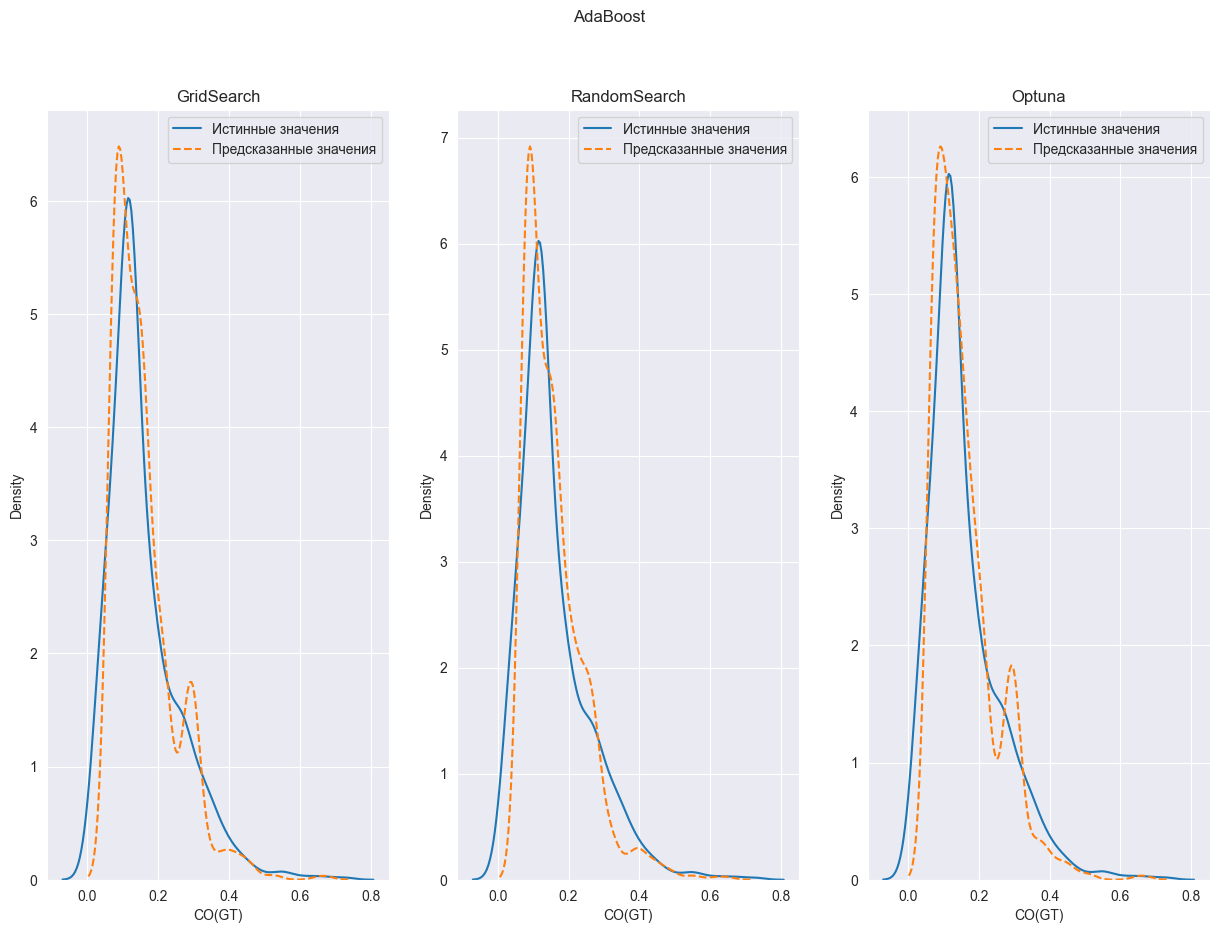

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, ab_models["AdaBoost"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"AdaBoost ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("AdaBoost")

По графикам видно, что модель AdaBoost обобщает данные хуже предыдущих моделей.

In [33]:
train_and_test_comparing

Train Data                          \
                                                 R2     MSE    RMSE     MAE   
GradientBoostingRegressor (GridSearch)         0.99  0.0001  0.0087  0.0059   
GradientBoostingRegressor (RandomSearch)       0.92  0.0008  0.0282  0.0196   
GradientBoostingRegressor (Optuna)             0.99  0.0001  0.0116  0.0084   
AdaBoost (GridSearch)                          0.82  0.0019  0.0435  0.0320   
AdaBoost (RandomSearch)                        0.81  0.0019  0.0438  0.0324   
AdaBoost (Optuna)                              0.82  0.0019  0.0437  0.0321   

                                                       Test Data          \
                                                  MAPE        R2     MSE   
GradientBoostingRegressor (GridSearch)    2.811780e+11      0.89  0.0012   
GradientBoostingRegressor (RandomSearch)  1.172402e+12      0.85  0.0016   
GradientBoostingRegressor (Optuna)        4.213881e+11      0.89  0.0011   
AdaBoost (GridSearch)                     1.550250e+12      0.78  0.0022   
AdaBoost (RandomSearch)                   1.587763e+12      0.79  0.0022   
AdaBoost (Optuna)                         1.509217e+12      0.78  0.0023   

                                                                  
                                            RMSE     MAE    MAPE  
GradientBoostingRegressor (GridSearch)    0.0341  0.0201  0.1935  
GradientBoostingRegressor (RandomSearch)  0.0399  0.0246  0.2457  
GradientBoostingRegressor (Optuna)        0.0339  0.0203  0.2035  
AdaBoost (GridSearch)                     0.0474  0.0331  0.3405  
AdaBoost (RandomSearch)                   0.0467  0.0332  0.3481  
AdaBoost (Optuna)                         0.0478  0.0335  0.3406

### StackingRegressor

In [42]:
rf = RandomForestRegressor(n_estimators=100, max_depth=20,
                           min_samples_split=2, min_samples_leaf=1, max_features=None)

stack_reg = StackingRegressor(estimators=[("poly", pipeline), ("forest", rf)])

stack_reg.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('poly', ...), ('forest', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",None
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",3
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,alpha,0.001


In [44]:
input_into_table(X_train, X_test, y_train, y_test, stack_reg, "Stacking Regressor")
train_and_test_comparing

Train Data                          \
                                                 R2     MSE    RMSE     MAE   
GradientBoostingRegressor (GridSearch)         0.99  0.0001  0.0087  0.0059   
GradientBoostingRegressor (RandomSearch)       0.92  0.0008  0.0282  0.0196   
GradientBoostingRegressor (Optuna)             0.99  0.0001  0.0116  0.0084   
AdaBoost (GridSearch)                          0.82  0.0019  0.0435  0.0320   
AdaBoost (RandomSearch)                        0.81  0.0019  0.0438  0.0324   
AdaBoost (Optuna)                              0.82  0.0019  0.0437  0.0321   
Stacking Regressor                             0.97  0.0003  0.0174  0.0113   

                                                       Test Data          \
                                                  MAPE        R2     MSE   
GradientBoostingRegressor (GridSearch)    2.811780e+11      0.89  0.0012   
GradientBoostingRegressor (RandomSearch)  1.172402e+12      0.85  0.0016   
GradientBoostingRegressor (Optuna)        4.213881e+11      0.89  0.0011   
AdaBoost (GridSearch)                     1.550250e+12      0.78  0.0022   
AdaBoost (RandomSearch)                   1.587763e+12      0.79  0.0022   
AdaBoost (Optuna)                         1.509217e+12      0.78  0.0023   
Stacking Regressor                        5.977661e+11      0.88  0.0013   

                                                                  
                                            RMSE     MAE    MAPE  
GradientBoostingRegressor (GridSearch)    0.0341  0.0201  0.1935  
GradientBoostingRegressor (RandomSearch)  0.0399  0.0246  0.2457  
GradientBoostingRegressor (Optuna)        0.0339  0.0203  0.2035  
AdaBoost (GridSearch)                     0.0474  0.0331  0.3405  
AdaBoost (RandomSearch)                   0.0467  0.0332  0.3481  
AdaBoost (Optuna)                         0.0478  0.0335  0.3406  
Stacking Regressor                        0.0360  0.0215  0.2094

Стэкинг тоже отработал неплохо, хотя хуже градиентного бустинга и случайного леса.

Text(0.5, 1.0, 'Stacking regressor')

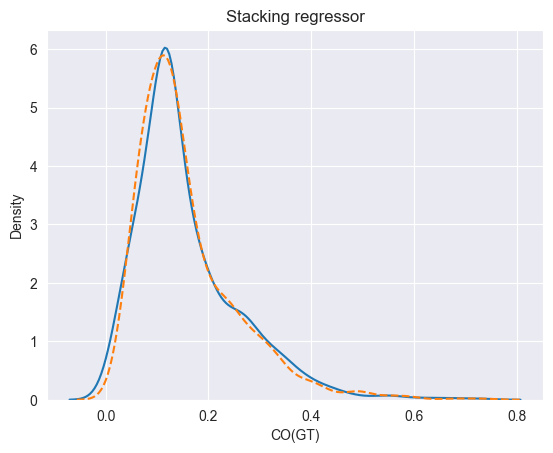

In [43]:
predict = stack_reg.predict(X_test)
sns.kdeplot(y_test, label="Истинные значения")
sns.kdeplot(predict, label="Предсказанные значения", linestyle="--")
plt.title("Stacking regressor")

### CatBoost

In [51]:
cb_config = {
    "CatBoost": {
        "model": CatBoostRegressor,
        "param_grid": {
                'iterations': [100, 200, 300, 400, 500],
                'learning_rate': [0.01, 0.05, 0.1],
                'depth': [4, 6, 8],
                'l2_leaf_reg': [1, 3, 5, 7, 9],
        }
    }
}

In [52]:
cb_models = train_models_with_cross_val(X_train, y_train, cb_config)

0:	learn: 0.0944085	total: 136ms	remaining: 1m 7s
1:	learn: 0.0877795	total: 142ms	remaining: 35.3s
2:	learn: 0.0816017	total: 147ms	remaining: 24.4s
3:	learn: 0.0761525	total: 152ms	remaining: 18.9s
4:	learn: 0.0709680	total: 158ms	remaining: 15.6s
5:	learn: 0.0665575	total: 163ms	remaining: 13.5s
6:	learn: 0.0626553	total: 169ms	remaining: 11.9s
7:	learn: 0.0591741	total: 174ms	remaining: 10.7s
8:	learn: 0.0561135	total: 180ms	remaining: 9.81s
9:	learn: 0.0534927	total: 186ms	remaining: 9.09s
10:	learn: 0.0510822	total: 192ms	remaining: 8.51s
11:	learn: 0.0488963	total: 197ms	remaining: 8.02s
12:	learn: 0.0471507	total: 203ms	remaining: 7.61s
13:	learn: 0.0455260	total: 208ms	remaining: 7.23s
14:	learn: 0.0440766	total: 214ms	remaining: 6.93s
15:	learn: 0.0428411	total: 220ms	remaining: 6.66s
16:	learn: 0.0417553	total: 226ms	remaining: 6.42s
17:	learn: 0.0408349	total: 231ms	remaining: 6.2s
18:	learn: 0.0400054	total: 237ms	remaining: 6s
19:	learn: 0.0392514	total: 243ms	remaining: 

[I 2026-04-16 08:43:51,330] A new study created in memory with name: no-name-0c17ce22-3038-419e-8b66-07b462d19b08


472:	learn: 0.0188564	total: 990ms	remaining: 56.5ms
473:	learn: 0.0188355	total: 992ms	remaining: 54.4ms
474:	learn: 0.0188239	total: 995ms	remaining: 52.3ms
475:	learn: 0.0188132	total: 997ms	remaining: 50.3ms
476:	learn: 0.0188030	total: 1000ms	remaining: 48.2ms
477:	learn: 0.0187731	total: 1s	remaining: 46.1ms
478:	learn: 0.0187625	total: 1s	remaining: 44ms
479:	learn: 0.0187492	total: 1.01s	remaining: 41.9ms
480:	learn: 0.0187330	total: 1.01s	remaining: 39.9ms
481:	learn: 0.0186960	total: 1.01s	remaining: 37.8ms
482:	learn: 0.0186738	total: 1.01s	remaining: 35.7ms
483:	learn: 0.0186620	total: 1.02s	remaining: 33.6ms
484:	learn: 0.0186439	total: 1.02s	remaining: 31.5ms
485:	learn: 0.0186261	total: 1.02s	remaining: 29.4ms
486:	learn: 0.0186160	total: 1.02s	remaining: 27.3ms
487:	learn: 0.0185829	total: 1.02s	remaining: 25.2ms
488:	learn: 0.0185687	total: 1.02s	remaining: 23.1ms
489:	learn: 0.0185473	total: 1.03s	remaining: 21ms
490:	learn: 0.0185349	total: 1.03s	remaining: 18.9ms
49

[I 2026-04-16 08:43:53,100] Trial 0 finished with value: 0.8630846674433267 and parameters: {'iterations': 300, 'learning_rate': 0.018423855049068863, 'depth': 4, 'l2_leaf_reg': 5}. Best is trial 0 with value: 0.8630846674433267.


118:	learn: 0.0429591	total: 129ms	remaining: 196ms
119:	learn: 0.0428507	total: 130ms	remaining: 195ms
120:	learn: 0.0427393	total: 131ms	remaining: 194ms
121:	learn: 0.0426309	total: 132ms	remaining: 192ms
122:	learn: 0.0425172	total: 133ms	remaining: 191ms
123:	learn: 0.0424163	total: 134ms	remaining: 190ms
124:	learn: 0.0423133	total: 135ms	remaining: 189ms
125:	learn: 0.0422078	total: 136ms	remaining: 188ms
126:	learn: 0.0421138	total: 137ms	remaining: 186ms
127:	learn: 0.0420157	total: 138ms	remaining: 185ms
128:	learn: 0.0419223	total: 139ms	remaining: 184ms
129:	learn: 0.0418325	total: 140ms	remaining: 183ms
130:	learn: 0.0417429	total: 141ms	remaining: 182ms
131:	learn: 0.0416448	total: 142ms	remaining: 181ms
132:	learn: 0.0415523	total: 143ms	remaining: 179ms
133:	learn: 0.0414780	total: 144ms	remaining: 178ms
134:	learn: 0.0413997	total: 145ms	remaining: 177ms
135:	learn: 0.0413173	total: 146ms	remaining: 176ms
136:	learn: 0.0412381	total: 147ms	remaining: 174ms
137:	learn: 

[I 2026-04-16 08:43:56,419] Trial 1 finished with value: 0.9120022793670076 and parameters: {'iterations': 400, 'learning_rate': 0.07241101984930039, 'depth': 6, 'l2_leaf_reg': 5}. Best is trial 1 with value: 0.9120022793670076.


308:	learn: 0.0251350	total: 465ms	remaining: 137ms
309:	learn: 0.0251026	total: 467ms	remaining: 136ms
310:	learn: 0.0250818	total: 469ms	remaining: 134ms
311:	learn: 0.0250795	total: 471ms	remaining: 133ms
312:	learn: 0.0250609	total: 472ms	remaining: 131ms
313:	learn: 0.0250378	total: 474ms	remaining: 130ms
314:	learn: 0.0250306	total: 476ms	remaining: 128ms
315:	learn: 0.0250090	total: 477ms	remaining: 127ms
316:	learn: 0.0249783	total: 479ms	remaining: 125ms
317:	learn: 0.0249390	total: 481ms	remaining: 124ms
318:	learn: 0.0249107	total: 482ms	remaining: 122ms
319:	learn: 0.0248774	total: 484ms	remaining: 121ms
320:	learn: 0.0248586	total: 485ms	remaining: 119ms
321:	learn: 0.0248271	total: 487ms	remaining: 118ms
322:	learn: 0.0248176	total: 489ms	remaining: 116ms
323:	learn: 0.0248044	total: 490ms	remaining: 115ms
324:	learn: 0.0247844	total: 492ms	remaining: 113ms
325:	learn: 0.0247516	total: 493ms	remaining: 112ms
326:	learn: 0.0247481	total: 495ms	remaining: 110ms
327:	learn: 

[I 2026-04-16 08:43:58,426] Trial 2 finished with value: 0.8954182825288072 and parameters: {'iterations': 100, 'learning_rate': 0.08444055248489007, 'depth': 8, 'l2_leaf_reg': 5}. Best is trial 1 with value: 0.9120022793670076.


77:	learn: 0.0306114	total: 274ms	remaining: 77.3ms
78:	learn: 0.0305263	total: 278ms	remaining: 74ms
79:	learn: 0.0304444	total: 282ms	remaining: 70.4ms
80:	learn: 0.0303786	total: 285ms	remaining: 66.9ms
81:	learn: 0.0302719	total: 288ms	remaining: 63.3ms
82:	learn: 0.0301619	total: 292ms	remaining: 59.8ms
83:	learn: 0.0301108	total: 295ms	remaining: 56.3ms
84:	learn: 0.0300263	total: 299ms	remaining: 52.7ms
85:	learn: 0.0299349	total: 302ms	remaining: 49.1ms
86:	learn: 0.0298586	total: 305ms	remaining: 45.6ms
87:	learn: 0.0297518	total: 309ms	remaining: 42.1ms
88:	learn: 0.0296871	total: 312ms	remaining: 38.6ms
89:	learn: 0.0295920	total: 315ms	remaining: 35ms
90:	learn: 0.0294831	total: 318ms	remaining: 31.5ms
91:	learn: 0.0293896	total: 322ms	remaining: 28ms
92:	learn: 0.0293448	total: 326ms	remaining: 24.5ms
93:	learn: 0.0292711	total: 329ms	remaining: 21ms
94:	learn: 0.0291947	total: 332ms	remaining: 17.5ms
95:	learn: 0.0290668	total: 335ms	remaining: 14ms
96:	learn: 0.0289867	t

[I 2026-04-16 08:43:59,579] Trial 3 finished with value: 0.879986874578886 and parameters: {'iterations': 200, 'learning_rate': 0.05243863757078262, 'depth': 4, 'l2_leaf_reg': 1}. Best is trial 1 with value: 0.9120022793670076.


0:	learn: 0.0977796	total: 4.26ms	remaining: 2.13s
1:	learn: 0.0947521	total: 8.35ms	remaining: 2.08s
2:	learn: 0.0920233	total: 11.8ms	remaining: 1.96s
3:	learn: 0.0892156	total: 15.4ms	remaining: 1.91s
4:	learn: 0.0865783	total: 18.9ms	remaining: 1.87s
5:	learn: 0.0839638	total: 22.5ms	remaining: 1.85s
6:	learn: 0.0815326	total: 26ms	remaining: 1.83s
7:	learn: 0.0791995	total: 29.7ms	remaining: 1.83s
8:	learn: 0.0769095	total: 33ms	remaining: 1.8s
9:	learn: 0.0748900	total: 36.3ms	remaining: 1.78s
10:	learn: 0.0728324	total: 39.7ms	remaining: 1.76s
11:	learn: 0.0707984	total: 42.9ms	remaining: 1.74s
12:	learn: 0.0689662	total: 46ms	remaining: 1.72s
13:	learn: 0.0672205	total: 49.5ms	remaining: 1.72s
14:	learn: 0.0656529	total: 52.8ms	remaining: 1.71s
15:	learn: 0.0640485	total: 56.1ms	remaining: 1.7s
16:	learn: 0.0625606	total: 59.4ms	remaining: 1.69s
17:	learn: 0.0611172	total: 62.6ms	remaining: 1.68s
18:	learn: 0.0598202	total: 65.9ms	remaining: 1.67s
19:	learn: 0.0585625	total: 69

[I 2026-04-16 08:44:09,725] Trial 4 finished with value: 0.9152479088226615 and parameters: {'iterations': 500, 'learning_rate': 0.04590011996445685, 'depth': 8, 'l2_leaf_reg': 7}. Best is trial 4 with value: 0.9152479088226615.


459:	learn: 0.0226157	total: 1.73s	remaining: 150ms
460:	learn: 0.0226019	total: 1.73s	remaining: 146ms
461:	learn: 0.0225837	total: 1.73s	remaining: 143ms
462:	learn: 0.0225710	total: 1.74s	remaining: 139ms
463:	learn: 0.0225536	total: 1.74s	remaining: 135ms
464:	learn: 0.0225282	total: 1.74s	remaining: 131ms
465:	learn: 0.0225005	total: 1.75s	remaining: 128ms
466:	learn: 0.0224788	total: 1.75s	remaining: 124ms
467:	learn: 0.0224679	total: 1.75s	remaining: 120ms
468:	learn: 0.0224545	total: 1.76s	remaining: 116ms
469:	learn: 0.0224388	total: 1.76s	remaining: 113ms
470:	learn: 0.0224274	total: 1.77s	remaining: 109ms
471:	learn: 0.0224040	total: 1.77s	remaining: 105ms
472:	learn: 0.0223878	total: 1.77s	remaining: 101ms
473:	learn: 0.0223757	total: 1.78s	remaining: 97.6ms
474:	learn: 0.0223736	total: 1.78s	remaining: 93.9ms
475:	learn: 0.0223440	total: 1.79s	remaining: 90.1ms
476:	learn: 0.0223140	total: 1.79s	remaining: 86.3ms
477:	learn: 0.0223062	total: 1.79s	remaining: 82.6ms
478:	le

[I 2026-04-16 08:44:12,543] Trial 5 finished with value: 0.8955937640776515 and parameters: {'iterations': 500, 'learning_rate': 0.05981174556724602, 'depth': 4, 'l2_leaf_reg': 9}. Best is trial 4 with value: 0.9152479088226615.


495:	learn: 0.0288500	total: 477ms	remaining: 3.85ms
496:	learn: 0.0288360	total: 479ms	remaining: 2.89ms
497:	learn: 0.0288269	total: 480ms	remaining: 1.93ms
498:	learn: 0.0288120	total: 481ms	remaining: 964us
499:	learn: 0.0288022	total: 482ms	remaining: 0us
0:	learn: 0.0949838	total: 1.53ms	remaining: 457ms
1:	learn: 0.0896493	total: 2.5ms	remaining: 373ms
2:	learn: 0.0849480	total: 3.52ms	remaining: 349ms
3:	learn: 0.0804932	total: 4.93ms	remaining: 365ms
4:	learn: 0.0763331	total: 5.86ms	remaining: 345ms
5:	learn: 0.0724321	total: 7.17ms	remaining: 351ms
6:	learn: 0.0690221	total: 8.3ms	remaining: 347ms
7:	learn: 0.0658220	total: 9.19ms	remaining: 335ms
8:	learn: 0.0630345	total: 10.1ms	remaining: 327ms
9:	learn: 0.0605586	total: 11.5ms	remaining: 334ms
10:	learn: 0.0583514	total: 12.5ms	remaining: 329ms
11:	learn: 0.0562396	total: 13.6ms	remaining: 326ms
12:	learn: 0.0542803	total: 14.7ms	remaining: 323ms
13:	learn: 0.0525463	total: 15.9ms	remaining: 324ms
14:	learn: 0.0510763	to

[I 2026-04-16 08:44:14,233] Trial 6 finished with value: 0.8969809471476976 and parameters: {'iterations': 300, 'learning_rate': 0.08884690857811085, 'depth': 4, 'l2_leaf_reg': 1}. Best is trial 4 with value: 0.9152479088226615.


277:	learn: 0.0280210	total: 277ms	remaining: 21.9ms
278:	learn: 0.0280085	total: 278ms	remaining: 20.9ms
279:	learn: 0.0279826	total: 279ms	remaining: 19.9ms
280:	learn: 0.0279624	total: 280ms	remaining: 19ms
281:	learn: 0.0279345	total: 281ms	remaining: 18ms
282:	learn: 0.0279243	total: 282ms	remaining: 17ms
283:	learn: 0.0278953	total: 283ms	remaining: 16ms
284:	learn: 0.0278732	total: 284ms	remaining: 15ms
285:	learn: 0.0278463	total: 285ms	remaining: 14ms
286:	learn: 0.0278293	total: 286ms	remaining: 13ms
287:	learn: 0.0278191	total: 287ms	remaining: 12ms
288:	learn: 0.0277988	total: 288ms	remaining: 11ms
289:	learn: 0.0277636	total: 290ms	remaining: 9.99ms
290:	learn: 0.0277463	total: 291ms	remaining: 8.99ms
291:	learn: 0.0277299	total: 292ms	remaining: 8ms
292:	learn: 0.0277147	total: 293ms	remaining: 7ms
293:	learn: 0.0276888	total: 294ms	remaining: 6ms
294:	learn: 0.0276586	total: 295ms	remaining: 5ms
295:	learn: 0.0276371	total: 296ms	remaining: 4ms
296:	learn: 0.0276158	tota

[I 2026-04-16 08:44:19,810] Trial 7 finished with value: 0.9169354481607481 and parameters: {'iterations': 300, 'learning_rate': 0.07944959629256831, 'depth': 8, 'l2_leaf_reg': 5}. Best is trial 7 with value: 0.9169354481607481.


250:	learn: 0.0219964	total: 861ms	remaining: 168ms
251:	learn: 0.0219777	total: 865ms	remaining: 165ms
252:	learn: 0.0219474	total: 869ms	remaining: 161ms
253:	learn: 0.0219065	total: 872ms	remaining: 158ms
254:	learn: 0.0218642	total: 875ms	remaining: 154ms
255:	learn: 0.0218361	total: 879ms	remaining: 151ms
256:	learn: 0.0217959	total: 882ms	remaining: 148ms
257:	learn: 0.0217475	total: 885ms	remaining: 144ms
258:	learn: 0.0217132	total: 889ms	remaining: 141ms
259:	learn: 0.0217050	total: 892ms	remaining: 137ms
260:	learn: 0.0216679	total: 895ms	remaining: 134ms
261:	learn: 0.0216398	total: 899ms	remaining: 130ms
262:	learn: 0.0215819	total: 902ms	remaining: 127ms
263:	learn: 0.0215444	total: 905ms	remaining: 123ms
264:	learn: 0.0215023	total: 908ms	remaining: 120ms
265:	learn: 0.0214610	total: 912ms	remaining: 117ms
266:	learn: 0.0214486	total: 915ms	remaining: 113ms
267:	learn: 0.0214073	total: 918ms	remaining: 110ms
268:	learn: 0.0213708	total: 921ms	remaining: 106ms
269:	learn: 

[I 2026-04-16 08:44:25,447] Trial 8 finished with value: 0.9166730849224042 and parameters: {'iterations': 300, 'learning_rate': 0.06414524003671741, 'depth': 8, 'l2_leaf_reg': 3}. Best is trial 7 with value: 0.9169354481607481.


265:	learn: 0.0219704	total: 905ms	remaining: 116ms
266:	learn: 0.0219244	total: 908ms	remaining: 112ms
267:	learn: 0.0218989	total: 911ms	remaining: 109ms
268:	learn: 0.0218432	total: 914ms	remaining: 105ms
269:	learn: 0.0218180	total: 917ms	remaining: 102ms
270:	learn: 0.0217657	total: 921ms	remaining: 98.6ms
271:	learn: 0.0217444	total: 924ms	remaining: 95.1ms
272:	learn: 0.0217093	total: 927ms	remaining: 91.7ms
273:	learn: 0.0216805	total: 931ms	remaining: 88.3ms
274:	learn: 0.0216657	total: 934ms	remaining: 84.9ms
275:	learn: 0.0216371	total: 937ms	remaining: 81.5ms
276:	learn: 0.0215938	total: 940ms	remaining: 78.1ms
277:	learn: 0.0215751	total: 944ms	remaining: 74.7ms
278:	learn: 0.0215217	total: 947ms	remaining: 71.3ms
279:	learn: 0.0215025	total: 951ms	remaining: 67.9ms
280:	learn: 0.0214778	total: 954ms	remaining: 64.5ms
281:	learn: 0.0214598	total: 958ms	remaining: 61.2ms
282:	learn: 0.0214452	total: 961ms	remaining: 57.8ms
283:	learn: 0.0214215	total: 966ms	remaining: 54.4m

[I 2026-04-16 08:44:34,806] Trial 9 finished with value: 0.9216250415884856 and parameters: {'iterations': 500, 'learning_rate': 0.06469481011062586, 'depth': 8, 'l2_leaf_reg': 5}. Best is trial 9 with value: 0.9216250415884856.


485:	learn: 0.0180181	total: 1.76s	remaining: 50.7ms
486:	learn: 0.0180053	total: 1.76s	remaining: 47.1ms
487:	learn: 0.0179618	total: 1.77s	remaining: 43.4ms
488:	learn: 0.0179444	total: 1.77s	remaining: 39.8ms
489:	learn: 0.0179283	total: 1.77s	remaining: 36.2ms
490:	learn: 0.0179026	total: 1.78s	remaining: 32.6ms
491:	learn: 0.0178944	total: 1.78s	remaining: 28.9ms
492:	learn: 0.0178692	total: 1.78s	remaining: 25.3ms
493:	learn: 0.0178551	total: 1.79s	remaining: 21.7ms
494:	learn: 0.0178438	total: 1.79s	remaining: 18.1ms
495:	learn: 0.0178232	total: 1.79s	remaining: 14.5ms
496:	learn: 0.0177962	total: 1.8s	remaining: 10.8ms
497:	learn: 0.0177732	total: 1.8s	remaining: 7.23ms
498:	learn: 0.0177575	total: 1.8s	remaining: 3.61ms
499:	learn: 0.0177309	total: 1.81s	remaining: 0us
0:	learn: 0.0987223	total: 2.12ms	remaining: 1.06s
1:	learn: 0.0965623	total: 4.14ms	remaining: 1.03s
2:	learn: 0.0944400	total: 6.41ms	remaining: 1.06s
3:	learn: 0.0922908	total: 8.2ms	remaining: 1.02s
4:	learn

[I 2026-04-16 08:44:38,965] Trial 10 finished with value: 0.9021153381744813 and parameters: {'iterations': 500, 'learning_rate': 0.031431251884937436, 'depth': 6, 'l2_leaf_reg': 3}. Best is trial 9 with value: 0.9216250415884856.


475:	learn: 0.0271137	total: 755ms	remaining: 38.1ms
476:	learn: 0.0270960	total: 757ms	remaining: 36.5ms
477:	learn: 0.0270779	total: 759ms	remaining: 34.9ms
478:	learn: 0.0270680	total: 760ms	remaining: 33.3ms
479:	learn: 0.0270574	total: 762ms	remaining: 31.7ms
480:	learn: 0.0270456	total: 763ms	remaining: 30.1ms
481:	learn: 0.0270209	total: 765ms	remaining: 28.6ms
482:	learn: 0.0270094	total: 766ms	remaining: 27ms
483:	learn: 0.0269905	total: 768ms	remaining: 25.4ms
484:	learn: 0.0269672	total: 769ms	remaining: 23.8ms
485:	learn: 0.0269547	total: 770ms	remaining: 22.2ms
486:	learn: 0.0269302	total: 772ms	remaining: 20.6ms
487:	learn: 0.0269190	total: 774ms	remaining: 19ms
488:	learn: 0.0269033	total: 775ms	remaining: 17.4ms
489:	learn: 0.0268878	total: 777ms	remaining: 15.8ms
490:	learn: 0.0268797	total: 778ms	remaining: 14.3ms
491:	learn: 0.0268718	total: 779ms	remaining: 12.7ms
492:	learn: 0.0268564	total: 781ms	remaining: 11.1ms
493:	learn: 0.0268336	total: 782ms	remaining: 9.5m

[I 2026-04-16 08:44:42,692] Trial 11 finished with value: 0.9123386252634343 and parameters: {'iterations': 200, 'learning_rate': 0.09967501169390006, 'depth': 8, 'l2_leaf_reg': 5}. Best is trial 9 with value: 0.9216250415884856.


0:	learn: 0.0956371	total: 4.54ms	remaining: 449ms
1:	learn: 0.0906684	total: 8.73ms	remaining: 428ms
2:	learn: 0.0863163	total: 13.3ms	remaining: 430ms
3:	learn: 0.0820351	total: 17.1ms	remaining: 411ms
4:	learn: 0.0781134	total: 20.4ms	remaining: 388ms
5:	learn: 0.0743806	total: 23.6ms	remaining: 370ms
6:	learn: 0.0710178	total: 26.8ms	remaining: 356ms
7:	learn: 0.0678308	total: 30.5ms	remaining: 351ms
8:	learn: 0.0649503	total: 33.8ms	remaining: 342ms
9:	learn: 0.0625794	total: 37.7ms	remaining: 340ms
10:	learn: 0.0602043	total: 40.9ms	remaining: 331ms
11:	learn: 0.0578616	total: 44.4ms	remaining: 326ms
12:	learn: 0.0559343	total: 47.6ms	remaining: 319ms
13:	learn: 0.0541255	total: 51.3ms	remaining: 315ms
14:	learn: 0.0525425	total: 54.5ms	remaining: 309ms
15:	learn: 0.0509883	total: 57.8ms	remaining: 303ms
16:	learn: 0.0494606	total: 61.4ms	remaining: 300ms
17:	learn: 0.0482097	total: 64.5ms	remaining: 294ms
18:	learn: 0.0470916	total: 67.7ms	remaining: 289ms
19:	learn: 0.0460216	t

[I 2026-04-16 08:44:44,654] Trial 12 finished with value: 0.892706749111974 and parameters: {'iterations': 100, 'learning_rate': 0.07633440432057612, 'depth': 8, 'l2_leaf_reg': 5}. Best is trial 9 with value: 0.9216250415884856.


91:	learn: 0.0300776	total: 317ms	remaining: 27.6ms
92:	learn: 0.0300256	total: 321ms	remaining: 24.2ms
93:	learn: 0.0299704	total: 325ms	remaining: 20.7ms
94:	learn: 0.0298796	total: 328ms	remaining: 17.3ms
95:	learn: 0.0298039	total: 331ms	remaining: 13.8ms
96:	learn: 0.0297275	total: 334ms	remaining: 10.3ms
97:	learn: 0.0296565	total: 338ms	remaining: 6.89ms
98:	learn: 0.0296037	total: 341ms	remaining: 3.44ms
99:	learn: 0.0295137	total: 344ms	remaining: 0us
0:	learn: 0.0978993	total: 5.01ms	remaining: 2s
1:	learn: 0.0950361	total: 9.23ms	remaining: 1.84s
2:	learn: 0.0923278	total: 13.5ms	remaining: 1.79s
3:	learn: 0.0896508	total: 17ms	remaining: 1.68s
4:	learn: 0.0871361	total: 20.6ms	remaining: 1.63s
5:	learn: 0.0846308	total: 24.3ms	remaining: 1.6s
6:	learn: 0.0823043	total: 27.5ms	remaining: 1.54s
7:	learn: 0.0800591	total: 30.8ms	remaining: 1.51s
8:	learn: 0.0778460	total: 34.1ms	remaining: 1.48s
9:	learn: 0.0758956	total: 37.8ms	remaining: 1.47s
10:	learn: 0.0739083	total: 41.

[I 2026-04-16 08:44:52,016] Trial 13 finished with value: 0.9078089480506517 and parameters: {'iterations': 400, 'learning_rate': 0.04424868780528843, 'depth': 8, 'l2_leaf_reg': 9}. Best is trial 9 with value: 0.9216250415884856.


389:	learn: 0.0252778	total: 1.32s	remaining: 34ms
390:	learn: 0.0252573	total: 1.33s	remaining: 30.6ms
391:	learn: 0.0252302	total: 1.33s	remaining: 27.2ms
392:	learn: 0.0252104	total: 1.34s	remaining: 23.8ms
393:	learn: 0.0251865	total: 1.34s	remaining: 20.4ms
394:	learn: 0.0251521	total: 1.34s	remaining: 17ms
395:	learn: 0.0251260	total: 1.35s	remaining: 13.6ms
396:	learn: 0.0250890	total: 1.35s	remaining: 10.2ms
397:	learn: 0.0250752	total: 1.35s	remaining: 6.81ms
398:	learn: 0.0250733	total: 1.36s	remaining: 3.4ms
399:	learn: 0.0250461	total: 1.36s	remaining: 0us
0:	learn: 0.0959787	total: 4.58ms	remaining: 1.37s
1:	learn: 0.0914155	total: 9.11ms	remaining: 1.36s
2:	learn: 0.0873285	total: 13.3ms	remaining: 1.32s
3:	learn: 0.0833143	total: 16.7ms	remaining: 1.24s
4:	learn: 0.0796395	total: 20.5ms	remaining: 1.21s
5:	learn: 0.0761279	total: 24ms	remaining: 1.18s
6:	learn: 0.0730934	total: 27.4ms	remaining: 1.15s
7:	learn: 0.0700002	total: 30.8ms	remaining: 1.12s
8:	learn: 0.0671677

[I 2026-04-16 08:44:57,753] Trial 14 finished with value: 0.9143999465923238 and parameters: {'iterations': 300, 'learning_rate': 0.07145968592823283, 'depth': 8, 'l2_leaf_reg': 7}. Best is trial 9 with value: 0.9216250415884856.


265:	learn: 0.0236138	total: 951ms	remaining: 122ms
266:	learn: 0.0235952	total: 955ms	remaining: 118ms
267:	learn: 0.0235721	total: 959ms	remaining: 115ms
268:	learn: 0.0235442	total: 963ms	remaining: 111ms
269:	learn: 0.0235061	total: 966ms	remaining: 107ms
270:	learn: 0.0234407	total: 970ms	remaining: 104ms
271:	learn: 0.0233922	total: 974ms	remaining: 100ms
272:	learn: 0.0233436	total: 977ms	remaining: 96.6ms
273:	learn: 0.0232871	total: 980ms	remaining: 93ms
274:	learn: 0.0232412	total: 983ms	remaining: 89.4ms
275:	learn: 0.0232074	total: 987ms	remaining: 85.8ms
276:	learn: 0.0231708	total: 990ms	remaining: 82.2ms
277:	learn: 0.0231461	total: 993ms	remaining: 78.6ms
278:	learn: 0.0230995	total: 996ms	remaining: 75ms
279:	learn: 0.0230675	total: 1000ms	remaining: 71.4ms
280:	learn: 0.0230415	total: 1s	remaining: 67.8ms
281:	learn: 0.0230120	total: 1.01s	remaining: 64.2ms
282:	learn: 0.0230018	total: 1.01s	remaining: 60.6ms
283:	learn: 0.0229565	total: 1.01s	remaining: 57ms
284:	lea

Text(0.5, 0.98, 'CatBoost')

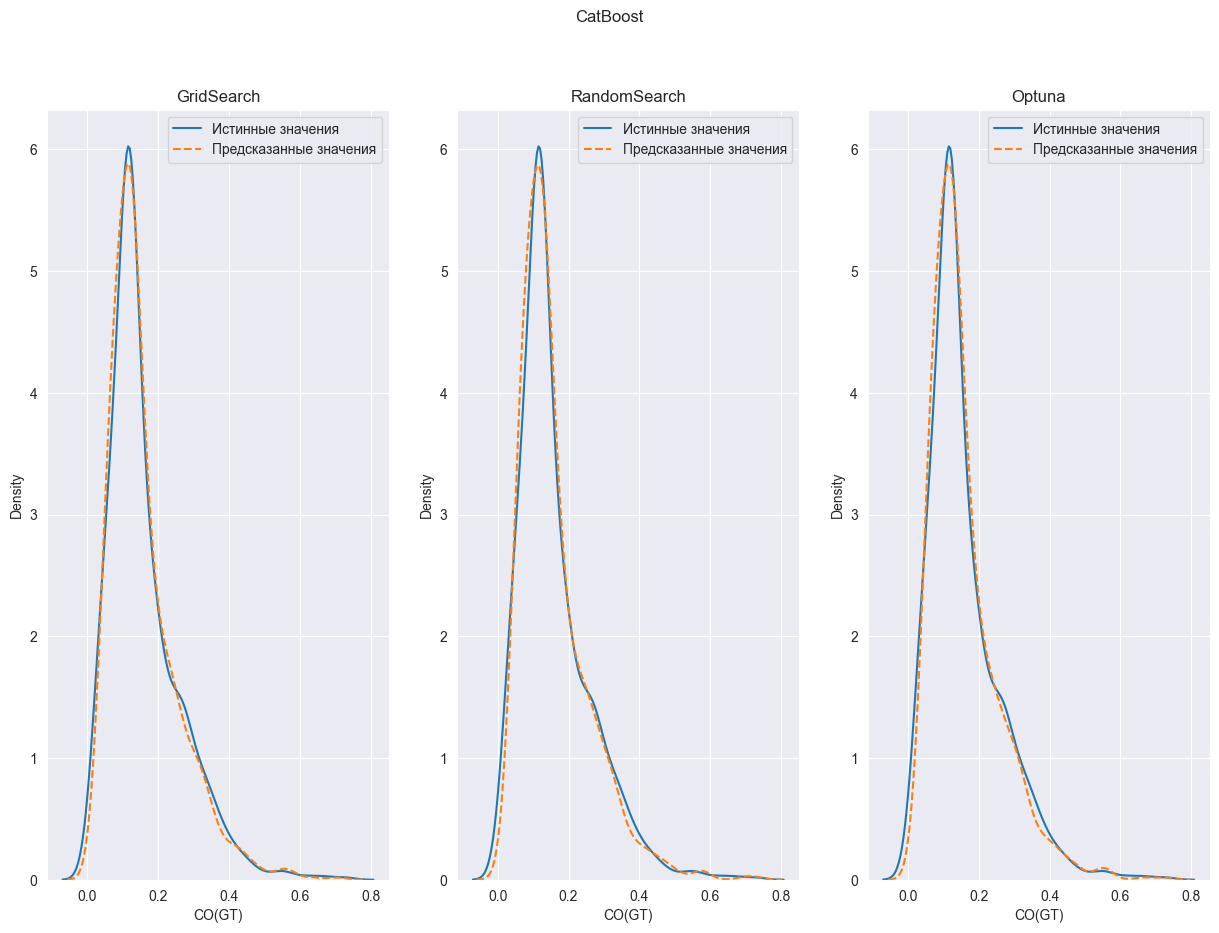

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, cb_models["CatBoost"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"CatBoost ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("CatBoost")

In [57]:
train_and_test_comparing

Train Data                          \
                                                 R2     MSE    RMSE     MAE   
GradientBoostingRegressor (GridSearch)         0.99  0.0001  0.0087  0.0059   
GradientBoostingRegressor (RandomSearch)       0.92  0.0008  0.0282  0.0196   
GradientBoostingRegressor (Optuna)             0.99  0.0001  0.0116  0.0084   
AdaBoost (GridSearch)                          0.82  0.0019  0.0435  0.0320   
AdaBoost (RandomSearch)                        0.81  0.0019  0.0438  0.0324   
AdaBoost (Optuna)                              0.82  0.0019  0.0437  0.0321   
Stacking Regressor                             0.97  0.0003  0.0174  0.0113   
CatBoost (GridSearch)                          0.99  0.0001  0.0112  0.0080   
CatBoost (RandomSearch)                        0.97  0.0003  0.0184  0.0131   
CatBoost (Optuna)                              0.97  0.0003  0.0180  0.0128   

                                                       Test Data          \
                                                  MAPE        R2     MSE   
GradientBoostingRegressor (GridSearch)    2.811780e+11      0.89  0.0012   
GradientBoostingRegressor (RandomSearch)  1.172402e+12      0.85  0.0016   
GradientBoostingRegressor (Optuna)        4.213881e+11      0.89  0.0011   
AdaBoost (GridSearch)                     1.550250e+12      0.78  0.0022   
AdaBoost (RandomSearch)                   1.587763e+12      0.79  0.0022   
AdaBoost (Optuna)                         1.509217e+12      0.78  0.0023   
Stacking Regressor                        5.977661e+11      0.88  0.0013   
CatBoost (GridSearch)                     3.684093e+11      0.90  0.0010   
CatBoost (RandomSearch)                   6.974351e+11      0.89  0.0012   
CatBoost (Optuna)                         7.203657e+11      0.89  0.0011   

                                                                  
                                            RMSE     MAE    MAPE  
GradientBoostingRegressor (GridSearch)    0.0341  0.0201  0.1935  
GradientBoostingRegressor (RandomSearch)  0.0399  0.0246  0.2457  
GradientBoostingRegressor (Optuna)        0.0339  0.0203  0.2035  
AdaBoost (GridSearch)                     0.0474  0.0331  0.3405  
AdaBoost (RandomSearch)                   0.0467  0.0332  0.3481  
AdaBoost (Optuna)                         0.0478  0.0335  0.3406  
Stacking Regressor                        0.0360  0.0215  0.2094  
CatBoost (GridSearch)                     0.0322  0.0186  0.1758  
CatBoost (RandomSearch)                   0.0341  0.0201  0.1967  
CatBoost (Optuna)                         0.0335  0.0198  0.1902

CatBoost также показал хорошие результаты - практически такие же хорошие, как и случайный лес.

### XGBRegressor

In [59]:
from xgboost import XGBRegressor

xgb_config = {
    "XGBoost": {
        "model": XGBRegressor,
        "param_grid": {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [4, 6, 8],
            'reg_lambda': [1, 3, 5, 7, 9],
            'tree_method': ['hist'],
        }
    }
}

In [60]:
xgb_models = train_models_with_cross_val(X_train, y_train, xgb_config)

[I 2026-04-16 08:53:06,814] A new study created in memory with name: no-name-b4146c93-cd82-458d-bd9b-916e2bf4c1d7
[I 2026-04-16 08:53:08,857] Trial 0 finished with value: 0.9175523131728548 and parameters: {'n_estimators': 500, 'learning_rate': 0.07586223883817708, 'max_depth': 6, 'reg_lambda': 5, 'tree_method': 'hist'}. Best is trial 0 with value: 0.9175523131728548.
[I 2026-04-16 08:53:10,133] Trial 1 finished with value: 0.9104545047080294 and parameters: {'n_estimators': 300, 'learning_rate': 0.049868267678916264, 'max_depth': 6, 'reg_lambda': 5, 'tree_method': 'hist'}. Best is trial 0 with value: 0.9175523131728548.
[I 2026-04-16 08:53:12,600] Trial 2 finished with value: 0.9164934251187267 and parameters: {'n_estimators': 500, 'learning_rate': 0.05003328848456801, 'max_depth': 6, 'reg_lambda': 3, 'tree_method': 'hist'}. Best is trial 0 with value: 0.9175523131728548.
[I 2026-04-16 08:53:13,560] Trial 3 finished with value: 0.904457370476566 and parameters: {'n_estimators': 400, '

Text(0.5, 0.98, 'XGBoost')

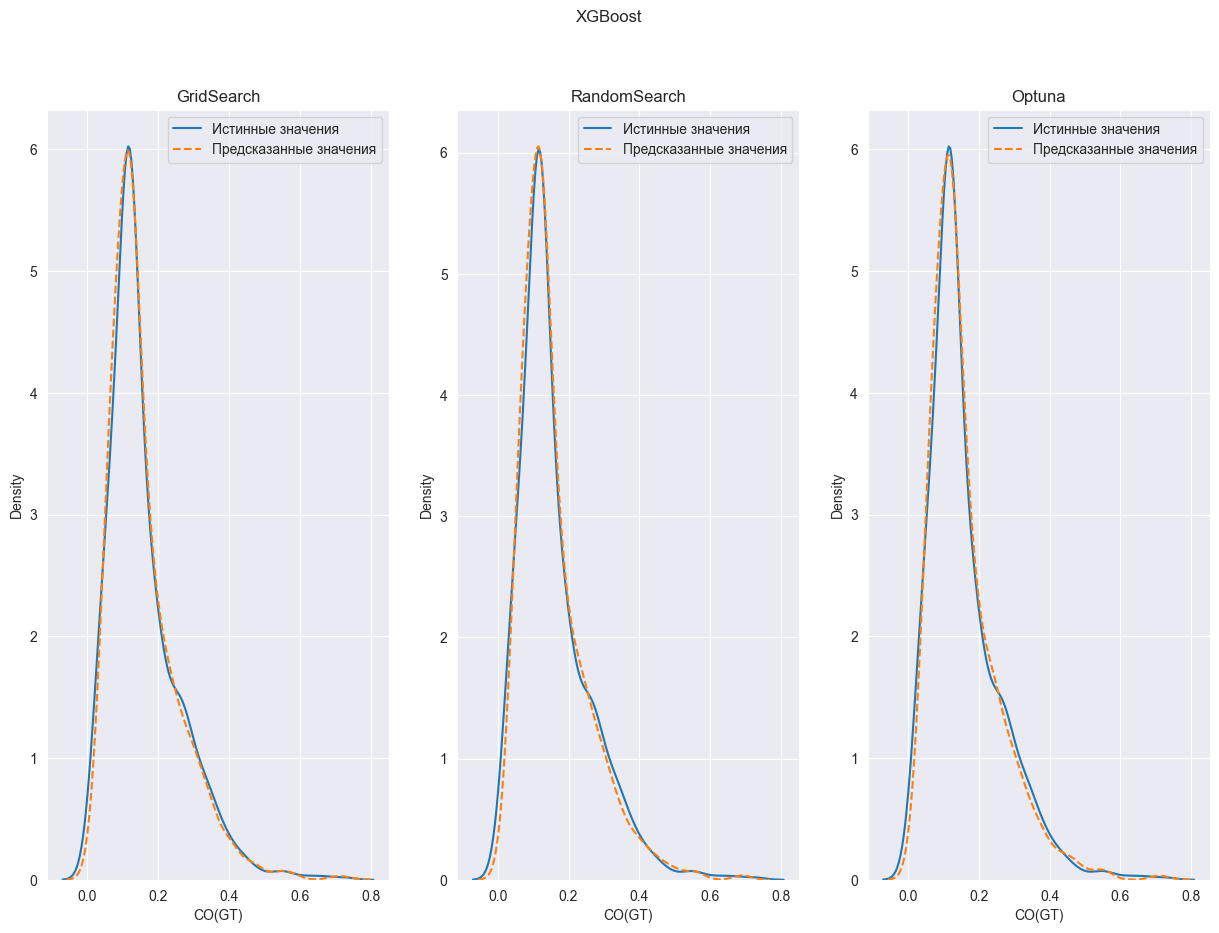

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, xgb_models["XGBoost"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"XGBoost ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("XGBoost")

In [64]:
train_and_test_comparing

Train Data                          \
                                                 R2     MSE    RMSE     MAE   
GradientBoostingRegressor (GridSearch)         0.99  0.0001  0.0087  0.0059   
GradientBoostingRegressor (RandomSearch)       0.92  0.0008  0.0282  0.0196   
GradientBoostingRegressor (Optuna)             0.99  0.0001  0.0116  0.0084   
AdaBoost (GridSearch)                          0.82  0.0019  0.0435  0.0320   
AdaBoost (RandomSearch)                        0.81  0.0019  0.0438  0.0324   
AdaBoost (Optuna)                              0.82  0.0019  0.0437  0.0321   
Stacking Regressor                             0.97  0.0003  0.0174  0.0113   
CatBoost (GridSearch)                          0.99  0.0001  0.0112  0.0080   
CatBoost (RandomSearch)                        0.97  0.0003  0.0184  0.0131   
CatBoost (Optuna)                              0.97  0.0003  0.0180  0.0128   
XGBoost (GridSearch)                           0.99  0.0001  0.0087  0.0058   
XGBoost (RandomSearch)                         0.99  0.0001  0.0107  0.0070   
XGBoost (Optuna)                               0.99  0.0001  0.0074  0.0046   

                                                       Test Data          \
                                                  MAPE        R2     MSE   
GradientBoostingRegressor (GridSearch)    2.811780e+11      0.89  0.0012   
GradientBoostingRegressor (RandomSearch)  1.172402e+12      0.85  0.0016   
GradientBoostingRegressor (Optuna)        4.213881e+11      0.89  0.0011   
AdaBoost (GridSearch)                     1.550250e+12      0.78  0.0022   
AdaBoost (RandomSearch)                   1.587763e+12      0.79  0.0022   
AdaBoost (Optuna)                         1.509217e+12      0.78  0.0023   
Stacking Regressor                        5.977661e+11      0.88  0.0013   
CatBoost (GridSearch)                     3.684093e+11      0.90  0.0010   
CatBoost (RandomSearch)                   6.974351e+11      0.89  0.0012   
CatBoost (Optuna)                         7.203657e+11      0.89  0.0011   
XGBoost (GridSearch)                      2.287024e+11      0.90  0.0010   
XGBoost (RandomSearch)                    4.286337e+11      0.89  0.0011   
XGBoost (Optuna)                          2.358590e+11      0.90  0.0011   

                                                                  
                                            RMSE     MAE    MAPE  
GradientBoostingRegressor (GridSearch)    0.0341  0.0201  0.1935  
GradientBoostingRegressor (RandomSearch)  0.0399  0.0246  0.2457  
GradientBoostingRegressor (Optuna)        0.0339  0.0203  0.2035  
AdaBoost (GridSearch)                     0.0474  0.0331  0.3405  
AdaBoost (RandomSearch)                   0.0467  0.0332  0.3481  
AdaBoost (Optuna)                         0.0478  0.0335  0.3406  
Stacking Regressor                        0.0360  0.0215  0.2094  
CatBoost (GridSearch)                     0.0322  0.0186  0.1758  
CatBoost (RandomSearch)                   0.0341  0.0201  0.1967  
CatBoost (Optuna)                         0.0335  0.0198  0.1902  
XGBoost (GridSearch)                      0.0319  0.0186  0.1784  
XGBoost (RandomSearch)                    0.0335  0.0191  0.1852  
XGBoost (Optuna)                          0.0327  0.0186  0.1776

XGBoost-регрессор тоже показал хорошие результаты - коэффициент R2 равен 0.9.

### LGBMRegressor

In [69]:
from lightgbm import LGBMRegressor

lgbm_config = {
    "LightGBM": {
        "model": LGBMRegressor,
        "param_grid": {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [4, 6, 8],
            'num_leaves': [15, 30],
        }
    }
}

In [70]:
lgbm_models = train_models_with_cross_val(X_train, y_train, lgbm_config)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000264 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2563
[LightGBM] [Info] Number of data points in the train set: 7100, number of used features: 15
[LightGBM] [Info] Start training from score 0.153526
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:03,461] A new study created in memory with name: no-name-2231a762-1251-4b3c-9089-b5c255e99ffe


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001102 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2560
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153033
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:04,076] Trial 0 finished with value: 0.902818501146859 and parameters: {'n_estimators': 400, 'learning_rate': 0.03784201643052922, 'max_depth': 6, 'num_leaves': 15}. Best is trial 0 with value: 0.902818501146859.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-16 09:23:04,842] Trial 1 finished with value: 0.8929876899581956 and parameters: {'n_estimators': 500, 'learning_rate': 0.01343593357478311, 'max_depth': 8, 'num_leaves': 15}. Best is trial 0 with value: 0.902818501146859.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2560
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153033
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:05,470] Trial 2 finished with value: 0.9152551860915722 and parameters: {'n_estimators': 500, 'learning_rate': 0.08456560061302715, 'max_depth': 6, 'num_leaves': 15}. Best is trial 2 with value: 0.9152551860915722.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-16 09:23:06,013] Trial 3 finished with value: 0.9147376851126772 and parameters: {'n_estimators': 400, 'learning_rate': 0.0881342781458404, 'max_depth': 8, 'num_leaves': 15}. Best is trial 2 with value: 0.9152551860915722.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000249 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

[I 2026-04-16 09:23:06,571] Trial 4 finished with value: 0.8923985038199753 and parameters: {'n_estimators': 500, 'learning_rate': 0.023379640363918784, 'max_depth': 4, 'num_leaves': 15}. Best is trial 2 with value: 0.9152551860915722.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153582
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:07,394] Trial 5 finished with value: 0.9180091667598165 and parameters: {'n_estimators': 400, 'learning_rate': 0.06455901064249853, 'max_depth': 8, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000236 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153803
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:08,091] Trial 6 finished with value: 0.9110013357620756 and parameters: {'n_estimators': 400, 'learning_rate': 0.04206494185939049, 'max_depth': 6, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000225 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2560
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153033
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:08,365] Trial 7 finished with value: 0.885580668620138 and parameters: {'n_estimators': 200, 'learning_rate': 0.03416331177378688, 'max_depth': 4, 'num_leaves': 15}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000245 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153803
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:09,263] Trial 8 finished with value: 0.916905616270452 and parameters: {'n_estimators': 500, 'learning_rate': 0.07191598221615177, 'max_depth': 6, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-16 09:23:09,729] Trial 9 finished with value: 0.9105739766388516 and parameters: {'n_estimators': 200, 'learning_rate': 0.05811937608719207, 'max_depth': 8, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153803
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:10,372] Trial 10 finished with value: 0.9147319952963849 and parameters: {'n_estimators': 300, 'learning_rate': 0.06103245291758802, 'max_depth': 8, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153803
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:10,622] Trial 11 finished with value: 0.9022741989055543 and parameters: {'n_estimators': 100, 'learning_rate': 0.07235997197070124, 'max_depth': 6, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-16 09:23:11,235] Trial 12 finished with value: 0.9158292081697297 and parameters: {'n_estimators': 300, 'learning_rate': 0.07185072646454725, 'max_depth': 8, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000215 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153803
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-04-16 09:23:11,477] Trial 13 finished with value: 0.9058739293370482 and parameters: {'n_estimators': 100, 'learning_rate': 0.09893924381465757, 'max_depth': 6, 'num_leaves': 30}. Best is trial 5 with value: 0.9180091667598165.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-04-16 09:23:12,353] Trial 14 finished with value: 0.9190745635635021 and parameters: {'n_estimators': 400, 'learning_rate': 0.07250096620788504, 'max_depth': 8, 'num_leaves': 30}. Best is trial 14 with value: 0.9190745635635021.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000310 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2561
[LightGBM] [Info] Number of data points in the train set: 5680, number of used features: 15
[LightGBM] [Info] Start training from score 0.153803
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

Text(0.5, 0.98, 'LightGBM')

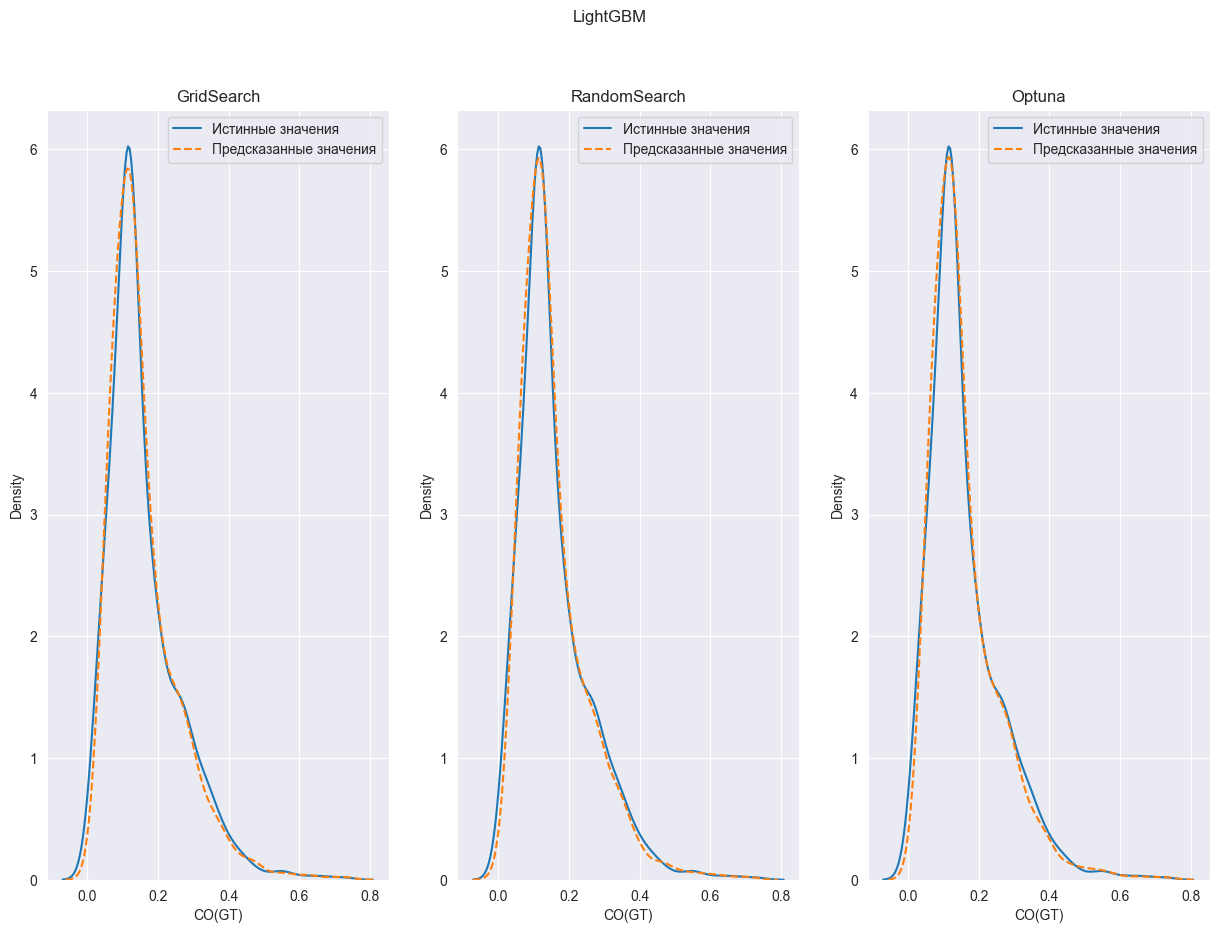

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
for ax, (name_of_method, model_info) in zip(axes, lgbm_models["LightGBM"].items()):
    model = model_info["model"]
    predict = model.predict(X_test)
    name_of_model = f"LightGBM ({name_of_method})"

    input_into_table(X_train, X_test, y_train, y_test, model, name_of_model)

    sns.kdeplot(y_test, label="Истинные значения", ax=ax)
    sns.kdeplot(predict, label="Предсказанные значения", ax=ax, linestyle="--")
    ax.set_title(name_of_method)
    ax.legend()

plt.suptitle("LightGBM")

In [72]:
train_and_test_comparing

Train Data                          \
                                                 R2     MSE    RMSE     MAE   
GradientBoostingRegressor (GridSearch)         0.99  0.0001  0.0087  0.0059   
GradientBoostingRegressor (RandomSearch)       0.92  0.0008  0.0282  0.0196   
GradientBoostingRegressor (Optuna)             0.99  0.0001  0.0116  0.0084   
AdaBoost (GridSearch)                          0.82  0.0019  0.0435  0.0320   
AdaBoost (RandomSearch)                        0.81  0.0019  0.0438  0.0324   
AdaBoost (Optuna)                              0.82  0.0019  0.0437  0.0321   
Stacking Regressor                             0.97  0.0003  0.0174  0.0113   
CatBoost (GridSearch)                          0.99  0.0001  0.0112  0.0080   
CatBoost (RandomSearch)                        0.97  0.0003  0.0184  0.0131   
CatBoost (Optuna)                              0.97  0.0003  0.0180  0.0128   
XGBoost (GridSearch)                           0.99  0.0001  0.0087  0.0058   
XGBoost (RandomSearch)                         0.99  0.0001  0.0107  0.0070   
XGBoost (Optuna)                               0.99  0.0001  0.0074  0.0046   
LightGBM (GridSearch)                          0.99  0.0001  0.0115  0.0080   
LightGBM (RandomSearch)                        0.98  0.0002  0.0132  0.0092   
LightGBM (Optuna)                              0.98  0.0002  0.0153  0.0105   

                                                       Test Data          \
                                                  MAPE        R2     MSE   
GradientBoostingRegressor (GridSearch)    2.811780e+11      0.89  0.0012   
GradientBoostingRegressor (RandomSearch)  1.172402e+12      0.85  0.0016   
GradientBoostingRegressor (Optuna)        4.213881e+11      0.89  0.0011   
AdaBoost (GridSearch)                     1.550250e+12      0.78  0.0022   
AdaBoost (RandomSearch)                   1.587763e+12      0.79  0.0022   
AdaBoost (Optuna)                         1.509217e+12      0.78  0.0023   
Stacking Regressor                        5.977661e+11      0.88  0.0013   
CatBoost (GridSearch)                     3.684093e+11      0.90  0.0010   
CatBoost (RandomSearch)                   6.974351e+11      0.89  0.0012   
CatBoost (Optuna)                         7.203657e+11      0.89  0.0011   
XGBoost (GridSearch)                      2.287024e+11      0.90  0.0010   
XGBoost (RandomSearch)                    4.286337e+11      0.89  0.0011   
XGBoost (Optuna)                          2.358590e+11      0.90  0.0011   
LightGBM (GridSearch)                     3.623063e+11      0.90  0.0010   
LightGBM (RandomSearch)                   4.431674e+11      0.90  0.0011   
LightGBM (Optuna)                         5.697335e+11      0.90  0.0011   

                                                                  
                                            RMSE     MAE    MAPE  
GradientBoostingRegressor (GridSearch)    0.0341  0.0201  0.1935  
GradientBoostingRegressor (RandomSearch)  0.0399  0.0246  0.2457  
GradientBoostingRegressor (Optuna)        0.0339  0.0203  0.2035  
AdaBoost (GridSearch)                     0.0474  0.0331  0.3405  
AdaBoost (RandomSearch)                   0.0467  0.0332  0.3481  
AdaBoost (Optuna)                         0.0478  0.0335  0.3406  
Stacking Regressor                        0.0360  0.0215  0.2094  
CatBoost (GridSearch)                     0.0322  0.0186  0.1758  
CatBoost (RandomSearch)                   0.0341  0.0201  0.1967  
CatBoost (Optuna)                         0.0335  0.0198  0.1902  
XGBoost (GridSearch)                      0.0319  0.0186  0.1784  
XGBoost (RandomSearch)                    0.0335  0.0191  0.1852  
XGBoost (Optuna)                          0.0327  0.0186  0.1776  
LightGBM (GridSearch)                     0.0323  0.0187  0.1815  
LightGBM (RandomSearch)                   0.0329  0.0192  0.1890  
LightGBM (Optuna)                         0.0329  0.0190  0.1807

LightGBM также показывает хорошие результаты.

### SketchBoost

In [73]:
from py_boost import SketchBoost
sb_config = {
    "SketchBoost": {
        "model": SketchBoost,
        "param_grid": {
            'loss': ['r2'],
            'ntrees': [100, 200, 500],
            'learning_rate': [0.05, 0.1],
            'max_depth': [4, 6]
        }
    }
}

C:\Users\79585\AppData\Local\Programs\Python\Python313\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


ImportError: Numba needs NumPy 2.3 or less. Got NumPy 2.4.

In [ ]:
sb_models = train_models_with_cross_val(X_train, y_train, sb_config)